In [1]:
import os

import yaml
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import torch

# Change the current working directory to the directory containing the config file
os.chdir("..")

In [2]:
# if processed_ROOT_file is available, use it instead of graphs_file
datasets = {
    "W wide mass": {
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt",
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07",
        "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt",
        "processed_ROOT_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wwidemass_1-50_ln_kT_cut_None.root",
        "source_ROOT_file": '/eos/home-t/tmlinare/Lund/jetetmiss/JETMDataMC/jpierre/run/submitDir-2025-01-06-1052-fee0 files 1-50/data-ANALYSIS/mc20_13TeV.802017.Py8EG_A14NNPDF23LO_WprimeWZ_flatpT_wideWmass.deriv.DAOD_JETM2.e8482_s3797_r13145_p5548.root',
        "config_signal": "W_flat"
    },
    "W real mass": {
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wrealmass_3-4_ln_kT_cut_None_with_pt"
        # "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07",
        "graphs_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt",
        "processed_ROOT_file": "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wrealmass_1-50_ln_kT_cut_None.root",
        "config_signal": "W"
    }
}

Dataset: W wide mass
Selected parameters for signal: W_flat

Using histogram file: ./histos/mass_40-300_pt_200-3100/WBSMP8_flat.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wwidemass_1-50_ln_kT_cut_None.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/jetetmiss/JETMDataMC/jpierre/run/submitDir-2025-01-06-1052-fee0 files 1-50/data-ANALYSIS/mc20_13TeV.802017.Py8EG_A14NNPDF23LO_WprimeWZ_flatpT_wideWmass.deriv.DAOD_JETM2.e8482_s3797_r13145_p5548.root


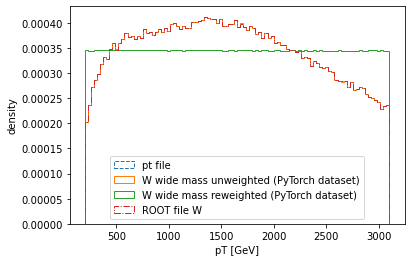

Dataset: W real mass
Selected parameters for signal: W

Using histogram file: ./histos/mass_40-300_pt_200-3100/WBSMP8.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wrealmass_1-50_ln_kT_cut_None.root


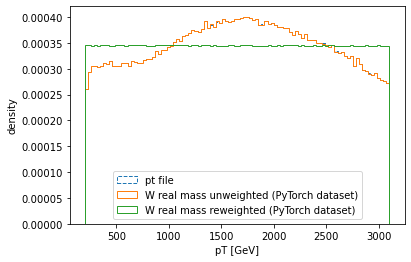

In [3]:
hist_params = dict(bins=100, histtype="step", density=True)

for dataset_label in datasets:
    print("Dataset:", dataset_label)

    # get the signal configuration from the YAML file
    with open("configs/config_signal.yaml") as f:
        config_signal = yaml.load(f, Loader=yaml.FullLoader)
    signal = datasets[dataset_label]["config_signal"]
    print("Selected parameters for signal:", signal)
    pt_min, pt_max = config_signal[signal]["pt_range"]
    m_min, m_max = config_signal[signal]["mass_range"]

    # plot histogram from hist file
    hist_filename = config_signal[signal]["pt_hist_file_signal"]
    print("\nUsing histogram file:", hist_filename)
    hist_file = uproot.open(hist_filename)

    bin_counts, bin_edges = hist_file["pt"].to_numpy()
    hist_pt_min_nonzero = bin_edges[np.nonzero(bin_counts)[0][0]]
    hist_pt_max_nonzero = bin_edges[np.nonzero(bin_counts)[0][-1]+1]

    bin_counts_mass, bin_edges_mass = hist_file["mass"].to_numpy()
    hist_mass_min_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][0]]
    hist_mass_max_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][-1]+1]

    if hist_pt_min_nonzero > pt_min or hist_pt_max_nonzero < pt_max:
        print(f"WARNING: pT histogram range with non-zero bin counts, {hist_pt_min_nonzero}-{hist_pt_max_nonzero} GeV, does not cover the config file range {pt_min}-{pt_max} GeV.")
    if hist_pt_min_nonzero < pt_min:
        print(f"WARNING: pT histogram range with non-zero bin counts starts at {hist_pt_min_nonzero} GeV, which is below the config file minimum {pt_min} GeV.")
        print("Check if the data used to create the histogram contains jets with pT below the config file minimum.")
        print("If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.")

    if hist_mass_min_nonzero != m_min or hist_mass_max_nonzero != m_max:
        print(f"WARNING: mass histogram range with non-zero bin counts, {hist_mass_min_nonzero}-{hist_mass_max_nonzero} GeV, does not match file range {m_min}-{m_max} GeV.")
        print("Different mass cuts result in different pT distributions.")

    hist_params["bins"] = bin_edges
    plt.hist(bin_edges[:-1], weights=bin_counts, label="pt file", linestyle="--", **hist_params)

    # plot pT distribution from PyTorch dataset
    if "processed_ROOT_file" in datasets[dataset_label]:
        ROOT_file = datasets[dataset_label]["processed_ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["FlatSubstructureJetTree"]
            pts = tree["fjet_pt"].array(library="numpy")
            masses = tree["fjet_m"].array(library="numpy")
            weights = tree["fjet_weight_pt"].array(library="numpy")
            ys = tree["labels"].array()

        signal_jet_truth_label = 2

    elif "graphs_file" in datasets[dataset_label]:
        graphs_filname = datasets[dataset_label]["graphs_file"]
        print("\nLoading graphs file:", graphs_filname)
        dataset = torch.load(graphs_filname)
        pts = np.array([jet.pt for jet in dataset])
        masses = np.array([jet.mass for jet in dataset])
        weights = np.array([jet.weights for jet in dataset])
        ys = np.array([jet.y for jet in dataset])

        signal_jet_truth_label = 1

    if pts.min() < pt_min or pts.max() > pt_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: pT values in dataset are outside the configured range {pt_min}-{pt_max} GeV.")
        print("Jets with pT outside this range may not have correct weights applied.")
        print(f"Minimum pT in dataset: {pts.min()} GeV, Maximum pT in dataset: {pts.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    if masses.min() < m_min or masses.max() > m_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: mass values in dataset are outside the configured range {m_min}-{m_max} GeV.")
        print(f"Minimum mass in dataset: {masses.min()} GeV, Maximum mass in dataset: {masses.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    plt.hist(pts[ys==signal_jet_truth_label], **hist_params, label=dataset_label+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==signal_jet_truth_label], weights=weights[ys==signal_jet_truth_label], **hist_params, label=dataset_label+" reweighted (PyTorch dataset)")

    # plot pT distribution from original ROOT file
    if "source_ROOT_file" in datasets[dataset_label]:
        signal_jet_truth_label = config_signal[signal]["signal_jet_truth_label"]

        ROOT_file = datasets[dataset_label]["source_ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            jet_masses = ak.flatten(tree["LRJ_mass"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

        mass_selection = (jet_masses > m_min) & (jet_masses < m_max)
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], label="ROOT file W", **hist_params, linestyle="-.")

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    # plt.savefig(f"tests/pt_hist_{dataset_label.replace(' ', '_')}.pdf")
    plt.show()

In [4]:
# function from utils_newdata, modified to return some additional values
def GetPtWeight(pts, truth_labels, dsid_input: int, SF: float = 5, signal_config_file: str = "configs/config_signal.yaml") -> np.array:
    """
    Return an array of weights for jets that make their pT distribution flat.

    Args:
        pts (array-like): Jet pT values.
        truth_labels (array-like): Integer large-R jet truth labels (e.g. 1 for tqqb, 2 for Wqq, 5 for Zqq, 10 for QCD).
        dsid_input (int): DSID of the input sample. It is assumed that all of the jets are from the same sample (or the same group of QCD samples).
        SF (float): Scale factor used for correct relative weighting of signal and background. Not important any more since weights are rescaled in training script to balance signal and background.
        signal_config_file (str): Path to the YAML configuration file for signal settings.
    Returns:
        np.array: An array of weights for the jets.
    """
    # get signal and backgound pT histograms
    with open(signal_config_file) as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    signal = "W_flat"

    filename_sig = config[signal]["pt_hist_file_signal"]
    filenames_bkg = config[signal]["pt_hist_files_bkg"]["files"]
    histos_dir = config[signal]["pt_hist_files_bkg"]["dir_path"]

    filename_Phythia = os.path.join(histos_dir, "qcdP8.root")  # default file for background jets if no match found
    filename_bkg = filename_Phythia

    print("DSID:", dsid_input)
    # only works if all the data in a single ROOT file is from the same DSID
    if dsid_input != config[signal]["dsid"]:
        found_background_file = False
        for filename, dsid_range in filenames_bkg.items():
            if dsid_range[0] <= dsid_input <= dsid_range[1]:
                filename_bkg = os.path.join(histos_dir, filename)
                found_background_file = True
                break
        if not found_background_file:
            print(f"WARNING: No histogram file found for DSID {dsid_input} for {signal} signal configuration.")

    print("Using signal file:", filename_sig)
    print("Using background file:", filename_bkg)

    weights_file_sig = uproot.open(filename_sig)
    bin_counts_sig, bin_edges_sig = weights_file_sig["pt"].to_numpy()
    nbins_sig = len(bin_counts_sig)

    weights_file_bkg = uproot.open(filename_bkg)
    bin_counts_bkg, bin_edges_bkg = weights_file_bkg["pt"].to_numpy()
    n_bins_bkg = len(bin_counts_bkg)

    # calculate scaling factor between signal and background using Pythia sample histogram
    filename_reweight = filename_Phythia
    weights_file_reweight = uproot.open(filename_reweight)
    bin_counts_bkg_reweight, _ = weights_file_reweight["pt"].to_numpy()
    total_jets_qcd = np.sum(bin_counts_bkg_reweight)
    total_jets_signal = np.sum(bin_counts_sig)
    print("proportion QCD_pythia/SIGNAL", total_jets_qcd / total_jets_signal)
    #ERRORRR
    QCD_SIGNAL_proportion = total_jets_qcd / total_jets_signal
    sig_bkg_proportion = SF #5  ## if is taked 5% of signal and 1% of qcd for training then sig_bkg_proportion=5
    scale_factor = (n_bins_bkg/nbins_sig) / sig_bkg_proportion #1
    scale_factor = scale_factor * QCD_SIGNAL_proportion
    print("scale factor:", scale_factor)

    # calculate the weight for each pT bin as the inverse of the bin count, with some scale factors
    Inv_hist_bg = np.where(
        bin_counts_bkg==0, 0,                                   # if bin count is zero, set weight to zero
        np.sum(bin_counts_bkg) / (n_bins_bkg * bin_counts_bkg)  # otherwise, calculate the inverse weight
    )
    Inv_hist_sig = np.where(
        bin_counts_sig==0, 0,
        np.sum(bin_counts_sig) / (nbins_sig * bin_counts_sig) * scale_factor
    )

    # for each jet pT, get the index of the corresponding pT bin
    pt_bin_indices_sig = np.digitize(pts, bin_edges_sig) - 1          # -1 to get zero-based indices
    pt_bin_indices_sig = np.clip(pt_bin_indices_sig, 0, nbins_sig-1)  # for bin indices above the last, change them to the index of the last bin
    pt_bin_indices_bkg = np.digitize(pts, bin_edges_bkg) - 1
    pt_bin_indices_bkg = np.clip(pt_bin_indices_bkg, 0, n_bins_bkg-1)

    # assign weight based on which pT bin the jet pT falls into and whether it is signal or background
    weights_out = np.where(
        truth_labels == 10,
        Inv_hist_bg[pt_bin_indices_bkg],
        Inv_hist_sig[pt_bin_indices_sig] # jets with label other than 10 are reweighted by the signal pT histogram, some of these are actually not signal and are removed later
    )

    return weights_out, Inv_hist_bg, Inv_hist_sig

In [5]:
with uproot.open(datasets["W wide mass"]["source_ROOT_file"]) as infile:
    tree = infile["AnalysisTree"]
    jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
flat_weights, Inv_hist_bg, Inv_hist_sig = GetPtWeight(jet_pts, truth_labels, dsid_input=802017, SF=5)

DSID: 802017
Using signal file: ./histos/mass_40-300_pt_200-3100/WBSMP8_flat.root
Using background file: ./histos/mass_40-300_pt_200-3100/qcdP8.root
proportion QCD_pythia/SIGNAL 10.914745
scale factor: 2.1829490661621094


In [6]:
flat_weights

<Array [2.02, 1.85, 1.93, ... 3.19, 1.92, 1.92] type='1904981 * float32'>

Text(0.5, 0, 'pT bin')

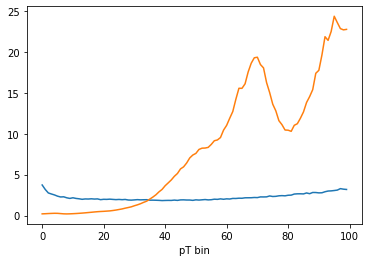

In [7]:
plt.plot(Inv_hist_sig, label="signal")
plt.plot(Inv_hist_bg, label="background")
plt.xlabel("pT bin")

Dataset: W wide mass
Selected parameters for signal: W_flat

Using histogram file: ./histos/mass_40-300_pt_200-3100/WBSMP8_flat.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wwidemass_1-50_ln_kT_cut_None.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/jetetmiss/JETMDataMC/jpierre/run/submitDir-2025-01-06-1052-fee0 files 1-50/data-ANALYSIS/mc20_13TeV.802017.Py8EG_A14NNPDF23LO_WprimeWZ_flatpT_wideWmass.deriv.DAOD_JETM2.e8482_s3797_r13145_p5548.root


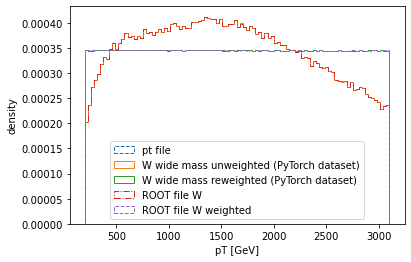

Dataset: W real mass
Selected parameters for signal: W

Using histogram file: ./histos/mass_40-300_pt_200-3100/WBSMP8.root

Loading ROOT file: /eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/v2.0.1.2/data_Wrealmass_1-50_ln_kT_cut_None.root


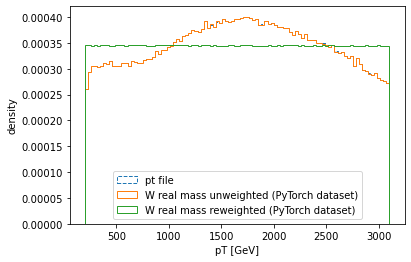

In [8]:
hist_params = dict(bins=100, histtype="step", density=True)

for dataset_label in datasets:
    print("Dataset:", dataset_label)

    # get the signal configuration from the YAML file
    with open("configs/config_signal.yaml") as f:
        config_signal = yaml.load(f, Loader=yaml.FullLoader)
    signal = datasets[dataset_label]["config_signal"]
    print("Selected parameters for signal:", signal)
    pt_min, pt_max = config_signal[signal]["pt_range"]
    m_min, m_max = config_signal[signal]["mass_range"]

    # plot histogram from hist file
    hist_filename = config_signal[signal]["pt_hist_file_signal"]
    print("\nUsing histogram file:", hist_filename)
    hist_file = uproot.open(hist_filename)

    bin_counts, bin_edges = hist_file["pt"].to_numpy()
    hist_pt_min_nonzero = bin_edges[np.nonzero(bin_counts)[0][0]]
    hist_pt_max_nonzero = bin_edges[np.nonzero(bin_counts)[0][-1]+1]

    bin_counts_mass, bin_edges_mass = hist_file["mass"].to_numpy()
    hist_mass_min_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][0]]
    hist_mass_max_nonzero = bin_edges_mass[np.nonzero(bin_counts_mass)[0][-1]+1]

    if hist_pt_min_nonzero > pt_min or hist_pt_max_nonzero < pt_max:
        print(f"WARNING: pT histogram range with non-zero bin counts, {hist_pt_min_nonzero}-{hist_pt_max_nonzero} GeV, does not cover the config file range {pt_min}-{pt_max} GeV.")
    if hist_pt_min_nonzero < pt_min:
        print(f"WARNING: pT histogram range with non-zero bin counts starts at {hist_pt_min_nonzero} GeV, which is below the config file minimum {pt_min} GeV.")
        print("Check if the data used to create the histogram contains jets with pT below the config file minimum.")
        print("If not, then the count for the first non-zero bin in the histogram is too low and results in the calculated flat-pT weights being too high for low-pT jets.")

    if hist_mass_min_nonzero != m_min or hist_mass_max_nonzero != m_max:
        print(f"WARNING: mass histogram range with non-zero bin counts, {hist_mass_min_nonzero}-{hist_mass_max_nonzero} GeV, does not match file range {m_min}-{m_max} GeV.")
        print("Different mass cuts result in different pT distributions.")

    hist_params["bins"] = bin_edges
    plt.hist(bin_edges[:-1], weights=bin_counts, label="pt file", linestyle="--", **hist_params)

    # plot pT distribution from PyTorch dataset
    if "processed_ROOT_file" in datasets[dataset_label]:
        ROOT_file = datasets[dataset_label]["processed_ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["FlatSubstructureJetTree"]
            pts = tree["fjet_pt"].array(library="numpy")
            masses = tree["fjet_m"].array(library="numpy")
            weights = tree["fjet_weight_pt"].array(library="numpy")
            ys = tree["labels"].array()

        signal_jet_truth_label = 2

    elif "graphs_file" in datasets[dataset_label]:
        graphs_filname = datasets[dataset_label]["graphs_file"]
        print("\nLoading graphs file:", graphs_filname)
        dataset = torch.load(graphs_filname)
        pts = np.array([jet.pt for jet in dataset])
        masses = np.array([jet.mass for jet in dataset])
        weights = np.array([jet.weights for jet in dataset])
        ys = np.array([jet.y for jet in dataset])

        signal_jet_truth_label = 1

    if pts.min() < pt_min or pts.max() > pt_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: pT values in dataset are outside the configured range {pt_min}-{pt_max} GeV.")
        print("Jets with pT outside this range may not have correct weights applied.")
        print(f"Minimum pT in dataset: {pts.min()} GeV, Maximum pT in dataset: {pts.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    if masses.min() < m_min or masses.max() > m_max:
        # TODO: or should I compare with hist_pt_min_nonzero and hist_pt_max_nonzero?
        print(f"WARNING: mass values in dataset are outside the configured range {m_min}-{m_max} GeV.")
        print(f"Minimum mass in dataset: {masses.min()} GeV, Maximum mass in dataset: {masses.max()} GeV.")
        print("Check if the dataset is correctly filtered to match the config file parameters.")

    plt.hist(pts[ys==signal_jet_truth_label], **hist_params, label=dataset_label+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==signal_jet_truth_label], weights=weights[ys==signal_jet_truth_label], **hist_params, label=dataset_label+" reweighted (PyTorch dataset)")

    # plot pT distribution from original ROOT file
    if "source_ROOT_file" in datasets[dataset_label]:
        signal_jet_truth_label = config_signal[signal]["signal_jet_truth_label"]

        ROOT_file = datasets[dataset_label]["source_ROOT_file"]
        print("\nLoading ROOT file:", ROOT_file)

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            jet_masses = ak.flatten(tree["LRJ_mass"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

        mass_selection = (jet_masses > m_min) & (jet_masses < m_max)
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], label="ROOT file W", **hist_params, linestyle="-.")

    if dataset_label == "W wide mass":
        pt_weights = flat_weights[(truth_labels==signal_jet_truth_label) & mass_selection]
        plt.hist(jet_pts[(truth_labels==signal_jet_truth_label) & mass_selection], weights=pt_weights, **hist_params, label="ROOT file W weighted", linestyle="--")

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    # plt.savefig(f"tests/pt_hist_{dataset_label.replace(' ', '_')}.pdf")
    plt.show()